In [1]:
import geopandas as gpd
from pyogrio import read_info

path = "../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_2020.shp"
# adjust the path if your notebook is somewhere else; use an absolute path if unsure

info = read_info(path)
print(info["features"], "features")
print(info["fields"])
print(info["dtypes"])

head = gpd.read_file(path, rows=5)
print(head.drop(columns="geometry"))
print(head.crs)

941872 features
['fire_ID' 'lat' 'lon' 'size' 'perimeter' 'start_date' 'start_DOY'
 'end_date' 'end_DOY' 'duration' 'fire_line' 'spread' 'speed' 'direction'
 'direc_frac' 'MODIS_tile' 'landcover' 'landc_frac' 'GFED_regio']
['int32' 'float64' 'float64' 'float64' 'float64' 'object' 'int32' 'object'
 'int32' 'int32' 'float64' 'float64' 'float64' 'object' 'float64' 'object'
 'object' 'float64' 'int32']
   fire_ID      lat      lon  size  perimeter  start_date  start_DOY  \
0    76988 -20.0104 -61.4981  1.50       5.56  2020-05-04        125   
1    76989 -20.0020 -59.4640  0.43       2.78  2020-09-23        267   
2    76995 -20.0020 -57.7790  3.64       9.26  2020-09-25        269   
3    76996 -20.0020 -57.6238  0.21       1.85  2020-06-26        178   
4    77012 -20.0020 -56.8922  0.43       2.78  2020-06-08        160   

     end_date  end_DOY  duration  fire_line  spread  speed direction  \
0  2020-05-08      129         5       0.65    0.30   0.67     north   
1  2020-09-23      26

In [2]:
import geopandas as gpd, pandas as pd

base = "../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_{}.shp"
frames = []
for yr in (2019, 2020, 2021, 2022):
    df = gpd.read_file(base.format(yr), ignore_geometry=True)
    df["start_date"] = pd.to_datetime(df["start_date"])
    df["file_year"] = yr
    print(yr, len(df), df["start_date"].min().date(), df["start_date"].max().date())
    frames.append(df)

fires = pd.concat(frames, ignore_index=True)
print("duplicate fire_IDs across files:", fires["fire_ID"].duplicated().sum())
print(fires["landcover"].value_counts())
print(fires["size"].describe())

2019 883922 2018-07-01 2020-05-31
2020 941872 2019-07-01 2021-05-31
2021 811489 2020-07-01 2022-05-31
2022 799297 2021-07-01 2023-05-31
duplicate fire_IDs across files: 2533584
landcover
Savannas                       1403956
Grasslands                      942749
Croplands                       376933
Woody savannas                  332643
Evergreen Broadleaf forest      141256
Deciduous Broadleaf forest      111465
Mixed forest                     67234
Open shrublands                  30203
Unclassified                      9836
Water                             7743
Evergreen Needleleaf forest       4590
Closed shrublands                 3576
Urban and built-up                3248
Deciduous Needleleaf forest       1136
Fill Value                          12
Name: count, dtype: int64
count    3.436580e+06
mean     4.017334e+00
std      2.736845e+01
min      2.100000e-01
25%      2.100000e-01
50%      8.600000e-01
75%      2.360000e+00
max      1.796905e+04
Name: size, dtype: float64

In [3]:
sel = fires[
    (fires["start_date"] >= "2020-01-01") & (fires["start_date"] < "2022-01-01")
    & (fires["size"] >= 5)          # about 500 ha, if size is in km2
].copy()
print(len(sel))
print(sel.groupby("landcover").size().sort_values(ascending=False))

239428
landcover
Savannas                       102524
Grasslands                      77903
Croplands                       18545
Woody savannas                  16846
Deciduous Broadleaf forest       9034
Mixed forest                     6014
Evergreen Broadleaf forest       3570
Open shrublands                  3567
Closed shrublands                 476
Unclassified                      447
Evergreen Needleleaf forest       386
Water                              51
Urban and built-up                 37
Deciduous Needleleaf forest        28
dtype: int64


In [4]:
dups = fires[fires.duplicated("fire_ID", keep=False)]
g = dups.groupby("fire_ID").agg(
    n=("file_year", "size"),
    n_lat=("lat", "nunique"),
    n_start=("start_date", "nunique"),
    n_size=("size", "nunique"),
)
print(g["n"].value_counts())
print((g[["n_lat", "n_start", "n_size"]] > 1).mean())   # share of IDs whose fields differ

n
4    759867
2     72024
5     39384
3     12189
6         9
Name: count, dtype: int64
n_lat      1.000000
n_start    0.999973
n_size     0.978144
dtype: float64


In [5]:
before = len(fires)
fires_u = fires.drop_duplicates(
    subset=["lat", "lon", "start_date", "end_date", "size"]).copy()
print("rows before:", before, " after:", len(fires_u), " removed:", before - len(fires_u))

# create your own unique ID, since fire_ID can't serve as one
fires_u["uid"] = fires_u["file_year"].astype(str) + "_" + fires_u["fire_ID"].astype(str)
print("uid unique:", fires_u["uid"].is_unique)

rows before: 3436580  after: 3397170  removed: 39410
uid unique: True


In [6]:
forest = ["Evergreen Broadleaf forest", "Deciduous Broadleaf forest", "Mixed forest",
          "Evergreen Needleleaf forest", "Deciduous Needleleaf forest"]

sel = fires_u[
    (fires_u["start_date"] >= "2020-01-01") & (fires_u["start_date"] < "2022-01-01")
    & (fires_u["size"] >= 5)
    & (fires_u["landcover"].isin(forest))
    & (fires_u["landc_frac"] >= 0.5)
].copy()

print(len(sel))
print(sel.groupby("landcover").size())
print(sel.groupby("GFED_regio").size())
print(sel["size"].describe())

16240
landcover
Deciduous Broadleaf forest     7736
Deciduous Needleleaf forest      16
Evergreen Broadleaf forest     3048
Evergreen Needleleaf forest     349
Mixed forest                   5091
dtype: int64
GFED_regio
1      124
2      238
3      287
4       59
5     1986
6       15
7       10
8     2167
9     7161
10     181
11      79
12    3781
13      17
14     135
dtype: int64
count    16240.000000
mean        19.328871
std         43.430675
min          5.140000
25%          6.860000
50%         10.290000
75%         18.860000
max       2977.800000
Name: size, dtype: float64


In [7]:
strata = (sel.groupby(["GFED_regio", "landcover"]).size()
             .rename("n_fires").reset_index())
print(strata.sort_values(["GFED_regio", "n_fires"], ascending=[True, False]).to_string(index=False))

top = (sel.sort_values("size", ascending=False)
          .groupby(["GFED_regio", "landcover"]).head(3)
          .sort_values(["GFED_regio", "landcover", "size"], ascending=[True, True, False]))
print(top[["uid", "GFED_regio", "landcover", "lat", "lon",
           "start_date", "end_date", "size"]].to_string(index=False))

 GFED_regio                   landcover  n_fires
          1 Evergreen Needleleaf forest      108
          1                Mixed forest       15
          1  Deciduous Broadleaf forest        1
          2 Evergreen Needleleaf forest      145
          2  Deciduous Broadleaf forest       51
          2  Evergreen Broadleaf forest       30
          2                Mixed forest       12
          3  Evergreen Broadleaf forest      141
          3  Deciduous Broadleaf forest      127
          3                Mixed forest       19
          4  Evergreen Broadleaf forest       51
          4  Deciduous Broadleaf forest        8
          5  Evergreen Broadleaf forest     1569
          5  Deciduous Broadleaf forest      406
          5                Mixed forest        9
          5 Evergreen Needleleaf forest        2
          6 Evergreen Needleleaf forest        9
          6  Deciduous Broadleaf forest        4
          6                Mixed forest        2
          7 Evergree

In [8]:
import os
os.makedirs("../data/processed", exist_ok=True)
sel.to_parquet("../data/processed/forest_fires_2020_2021_attrs.parquet")

In [9]:
import geopandas as gpd, os

path = "../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_2020.shp"
pilot = gpd.read_file(path, engine="pyogrio", where="fire_ID = 112")

print(pilot.drop(columns="geometry").T)   # check start_date 2020-08-14, size 1206.04
print(pilot.total_bounds)                 # minx, miny, maxx, maxy
os.makedirs("../data/processed/pilot", exist_ok=True)
pilot.to_file("../data/processed/pilot/fire_2020_112.gpkg", driver="GPKG")

                                      0
fire_ID                             112
lat                             39.6938
lon                            -122.782
size                            1206.04
perimeter                        308.36
start_date                   2020-08-14
start_DOY                           227
end_date                     2020-09-27
end_DOY                             271
duration                             45
fire_line                         39.34
spread                             26.8
speed                              4.42
direction                     northwest
direc_frac                         0.37
MODIS_tile                       h08v05
landcover   Evergreen Needleleaf forest
landc_frac                          0.5
GFED_regio                            2
[-123.09298503   39.5125     -122.55808696   39.87916666]


In [10]:
import rasterio
from rasterio.windows import from_bounds

url = "https://glad.geog.umd.edu/Potapov/Forest_height_2019/Forest_height_2019_NAM.tif"
west, south, east, north = -123.093, 39.5125, -122.558, 39.8792

with rasterio.open(url) as src:
    print(src.crs, src.res)
    win = from_bounds(west, south, east, north, src.transform)
    h = src.read(1, window=win)
print(h.shape)

EPSG:4326 (0.00025, 0.00025)
(1467, 2140)


In [11]:
import numpy as np
valid = h[h <= 60]          # 101 water, 102 snow/ice, 103 no data
print("share valid:", valid.size / h.size)
print("height percentiles (5, 25, 50, 75, 95):", np.percentile(valid, [5, 25, 50, 75, 95]))

share valid: 0.999959546152425
height percentiles (5, 25, 50, 75, 95): [ 0.  7. 15. 24. 34.]


In [12]:
import os, io, datetime as dt, requests, pandas as pd

os.environ["FIRMS_MAP_KEY"] = "694f59d089b8dab51c7e4c1094067706"
KEY = os.environ["FIRMS_MAP_KEY"]

bbox = "-123.15,39.46,-122.50,39.93"
start, end = dt.date(2020, 8, 1), dt.date(2020, 10, 15)

# check the exact source names and dates available first
print(requests.get(f"https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/{KEY}/all").text)

frames = []
for src in ["VIIRS_SNPP_SP", "VIIRS_NOAA20_SP"]:   # confirm names against the availability list
    d = start
    while d <= end:
        n = min(5, (end - d).days + 1)
        r = requests.get(f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{KEY}/{src}/{bbox}/{n}/{d}", timeout=60)
        if r.text.startswith("latitude"):
            df = pd.read_csv(io.StringIO(r.text)); df["source"] = src; frames.append(df)
        else:
            print(src, d, r.text[:100])
        d += dt.timedelta(days=n)

firms = pd.concat(frames, ignore_index=True)
os.makedirs("../data/firms", exist_ok=True)
firms.to_parquet("../data/firms/pilot_2020_112.parquet")
print(len(firms)); print(firms[["acq_date", "frp", "confidence", "daynight"]].describe(include="all"))

data_id,min_date,max_date
MODIS_NRT,2026-07-01,2026-10-07
MODIS_SP,2000-11-01,2026-06-30
VIIRS_NOAA20_NRT,2026-07-01,2026-10-07
VIIRS_NOAA20_SP,2018-04-01,2026-06-30
VIIRS_NOAA21_NRT,2024-01-17,2026-10-07
VIIRS_SNPP_NRT,2026-07-01,2026-10-07
VIIRS_SNPP_SP,2012-01-20,2026-06-30
LANDSAT_NRT,2022-06-20,2026-10-07
GOES_NRT,2022-08-09,2026-10-07
BA_MODIS,2000-11-01,2026-07-01
BA_VIIRS,2012-03-01,2026-07-01
59054
          acq_date       frp confidence daynight
count        59054  59054.00      59054    59054
unique          57   5579.00          3        2
top     2020-08-20      1.48          n        N
freq          4699    133.00      52747    39174


In [13]:
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize

fire = gpd.read_file("../data/processed/pilot/fire_2020_112.gpkg")
w, s, e, n = fire.total_bounds
base = "../data/tyukavina/NAM_fire_forest_loss_2001-25{}.tif"

arrs = {}
for tag in ["", "_annual"]:
    with rasterio.open(base.format(tag)) as src:
        print(tag or "base", src.crs, src.res, src.dtypes[0], src.nodata)
        win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
        arrs[tag] = src.read(1, window=win)
        tr = src.window_transform(win)

assert arrs[""].shape == arrs["_annual"].shape
mask = rasterize([(g, 1) for g in fire.geometry], out_shape=arrs[""].shape,
                 transform=tr, fill=0, dtype="uint8").astype(bool)

for tag, a in arrs.items():
    v, c = np.unique(a[mask], return_counts=True)
    print(tag or "base", dict(zip(v.tolist(), c.tolist())))
print(pd.crosstab(arrs[""][mask], arrs["_annual"][mask]))

base EPSG:4326 (0.00025, 0.00025) uint8 None
_annual EPSG:4326 (0.00025, 0.00025) uint8 None
base {0: 826585, 1: 59007, 2: 28273, 3: 57862, 4: 1059831}
_annual {0: 913865, 1: 5220, 2: 290, 3: 12909, 4: 10912, 5: 1662, 6: 11917, 7: 19979, 8: 10418, 9: 2480, 10: 623, 11: 46, 12: 11021, 13: 4376, 14: 761, 15: 3, 16: 123, 17: 49, 18: 643, 19: 595, 20: 708421, 21: 308929, 22: 4636, 23: 1308, 24: 369, 25: 3}
col_0      0     1    2      3     4     5      6      7     8     9   ...  \
row_0                                                                  ...   
0      826585     0    0      0     0     0      0      0     0     0  ...   
1       59007     0    0      0     0     0      0      0     0     0  ...   
2       28273     0    0      0     0     0      0      0     0     0  ...   
3           0   604  228    591  2336  1002   1279   4676  1000  1100  ...   
4           0  4616   62  12318  8576   660  10638  15303  9418  1380  ...   

col_0   16  17   18   19      20      21    22 

In [14]:
firms = pd.read_parquet("../data/firms/pilot_2020_112.parquet")
pts = gpd.GeoDataFrame(firms, geometry=gpd.points_from_xy(firms.longitude, firms.latitude), crs=4326)

poly = fire.to_crs(32610).buffer(500).to_crs(4326).iloc[0]   # fire polygon plus a 500 m margin
inside = pts[pts.within(poly) & (pts["confidence"] != "l")]
print(len(pts), "->", len(inside))
print("first/last detection:", inside.acq_date.min(), inside.acq_date.max())

daily = inside.groupby("acq_date").agg(n=("frp", "size"), frp_sum=("frp", "sum"), frp_max=("frp", "max"))
print(daily.to_string())
print(inside["frp"].describe())

59054 -> 35162
first/last detection: 2020-08-16 2020-10-12
               n    frp_sum  frp_max
acq_date                            
2020-08-16    11    1201.74   390.78
2020-08-17   118    1764.38   154.56
2020-08-18   189    3289.49   263.48
2020-08-19  3221  105085.56   670.48
2020-08-20  3712   88971.65  2051.62
2020-08-21  1841   26414.26   378.43
2020-08-22  1321   18324.92   248.89
2020-08-23  1466   19622.25   435.63
2020-08-24   335   10501.98   748.89
2020-08-25   953    4568.72   212.04
2020-08-26   582    2681.15    90.22
2020-08-27   711    8211.79   183.64
2020-08-28   856    6635.35   166.07
2020-08-29   687    3426.29    52.88
2020-08-30   721    4074.77    73.20
2020-08-31   979   11456.20   256.01
2020-09-01  1384   28101.35   793.28
2020-09-02  1090    9560.25   234.85
2020-09-03   670    4747.44   120.62
2020-09-04   741    8691.91   176.52
2020-09-05  1466   37488.23   509.80
2020-09-06   998   10369.63   221.63
2020-09-07  1225   24641.17   512.49
2020-09-08  2652

In [15]:
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling

fire = gpd.read_file("../data/processed/pilot/fire_2020_112.gpkg")
inner = fire.to_crs(32610).buffer(-500).to_crs(4326)        # burn minus outer 500 m

pad = 0.15
w, s, e, n = fire.total_bounds
w, s, e, n = w - pad, s - pad, e + pad, n + pad

# --- CCI biomass (100 m grid) ---
agb = {}
for yr in (2019, 2021, 2022):
    f = f"../data/cci_agb/N40W130_ESACCI-BIOMASS-L4-AGB-MERGED-100m-{yr}-fv6.0.tif"
    with rasterio.open(f) as src:
        win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
        agb[yr] = src.read(1, window=win, masked=True).astype("float64").filled(np.nan)
        tr_ref = src.window_transform(win)
shape = agb[2019].shape

m_inner = rasterize([(g, 1) for g in inner.geometry], out_shape=shape,
                    transform=tr_ref, fill=0, dtype="uint8").astype(bool)
valid = (np.isfinite(agb[2019]) & np.isfinite(agb[2021]) & np.isfinite(agb[2022]) & (agb[2019] > 10))

# --- Tyukavina fire-loss layers (30 m grid), same window ---
base = "../data/tyukavina/NAM_fire_forest_loss_2001-25{}.tif"
t = {}
for tag in ["", "_annual"]:
    with rasterio.open(base.format(tag)) as src:
        win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
        t[tag] = src.read(1, window=win)
        tr_t = src.window_transform(win)

fire_px  = np.isin(t[""], [3, 4])
this_fire = fire_px & np.isin(t["_annual"], [20, 21])                     # 2020 or 2021
other_fire = fire_px & (np.isin(t["_annual"], list(range(1, 20))) | np.isin(t["_annual"], [22, 23, 24, 25]))

def to_biomass_grid(a):
    out = np.zeros(shape, dtype="float32")
    reproject(a.astype("float32"), out, src_transform=tr_t, src_crs="EPSG:4326",
              dst_transform=tr_ref, dst_crs="EPSG:4326", resampling=Resampling.average)
    return out

frac  = to_biomass_grid(this_fire)    # share of each 100 m cell flagged as loss from this fire
prior = to_biomass_grid(other_fire)   # share flagged as loss from other years' fires

m = m_inner & valid & (prior <= 0.05)
print("cells kept:", int(m.sum()), "of", int((m_inner & valid).sum()))

d = pd.DataFrame({"frac": frac[m], "a19": agb[2019][m], "a21": agb[2021][m], "a22": agb[2022][m]})
d["bin"] = pd.cut(d["frac"], [-0.001, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0])
g = d.groupby("bin", observed=True)
out = g[["a19", "a21", "a22"]].sum()
out["n"] = g.size()
out["loss21"] = 1 - out["a21"] / out["a19"]
out["loss22"] = 1 - out["a22"] / out["a19"]
print(out[["n", "loss21", "loss22"]])

cells kept: 111521 of 125856
                    n    loss21    loss22
bin                                      
(-0.001, 0.05]  24760  0.004990  0.043584
(0.05, 0.25]     9957  0.018839  0.038067
(0.25, 0.5]     10083  0.028075  0.050619
(0.5, 0.75]     11440  0.031689  0.045315
(0.75, 0.95]    15090  0.040014  0.065745
(0.95, 1.0]     40191  0.064791  0.104574


In [16]:
bins = [-0.001, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]

with rasterio.open("../data/cci_agb/N40W130_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2018-fv6.0.tif") as src:
    win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
    a18 = src.read(1, window=win, masked=True).astype("float64").filled(np.nan)

m2 = m & np.isfinite(a18)
d2 = pd.DataFrame({"frac": frac[m2], "a18": a18[m2], "a19": agb[2019][m2]})
d2["bin"] = pd.cut(d2["frac"], bins)
g2 = d2.groupby("bin", observed=True)[["a18", "a19"]].sum()
g2["loss_2018_to_2019"] = 1 - g2["a19"] / g2["a18"]
print(g2[["loss_2018_to_2019"]])

print(d.groupby("bin", observed=True)["a19"].mean())


                loss_2018_to_2019
bin                              
(-0.001, 0.05]          -0.034773
(0.05, 0.25]            -0.023821
(0.25, 0.5]             -0.021587
(0.5, 0.75]             -0.016288
(0.75, 0.95]            -0.015098
(0.95, 1.0]             -0.004145
bin
(-0.001, 0.05]    93.461026
(0.05, 0.25]      93.949081
(0.25, 0.5]       92.503124
(0.5, 0.75]       90.388024
(0.75, 0.95]      88.122531
(0.95, 1.0]       86.131746
Name: a19, dtype: float64


## Fire severity (dNBR) for the pilot fire

Uses Sentinel-2 via Earth Engine. One-time setup on the instance, if not already done:

```python
import ee
ee.Authenticate()   # opens a browser link once, then caches a token
```

Pre-fire image: a clear composite from the season before the fire started (2020-08-14), so July 2020.
Post-fire image: the same season one year later (July-August 2021), per the roadmap, so that normal seasonal change is not mistaken for fire damage.

In [17]:
import ee

# full (non-read-only) scopes are needed since we export to Cloud Storage below,
# which requires write access, not just read access to imagery
ee.Authenticate()
ee.Initialize(project="tree-fire-510209")   # the project ID, not the "tree-fire" display name

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [18]:
import ee, geemap
import geopandas as gpd


fire = gpd.read_file("../data/processed/pilot/fire_2020_112.gpkg")
pad = 0.15
w_pad, s_pad, e_pad, n_pad = fire.total_bounds
w_pad, s_pad, e_pad, n_pad = w_pad - pad, s_pad - pad, e_pad + pad, n_pad + pad
aoi = ee.Geometry.Rectangle([w_pad, s_pad, e_pad, n_pad])

def mask_s2_clouds(img):
    qa = img.select("QA60")
    mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return img.updateMask(mask).divide(10000)

def nbr(img):
    return img.normalizedDifference(["B8", "B12"]).rename("NBR")

def composite(start, end):
    coll = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(aoi)
            .filterDate(start, end)
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
            .map(mask_s2_clouds))
    print(start, end, "images:", coll.size().getInfo())
    return nbr(coll.median())

nbr_pre = composite("2020-07-01", "2020-08-10")
nbr_post = composite("2021-07-01", "2021-08-31")
dnbr = nbr_pre.subtract(nbr_post).rename("dNBR").clip(aoi)

2020-07-01 2020-08-10 images: 54
2021-07-01 2021-08-31 images: 79


In [19]:
task = ee.batch.Export.image.toCloudStorage(
    image=dnbr,
    description="dnbr_2020_112",
    bucket="tree-fire-510209-data",
    fileNamePrefix="fire-impact-curves/data/severity/dnbr_2020_112",
    region=aoi,
    scale=30,
    maxPixels=1e9,
)
task.start()

# direct getDownloadURL/geemap.ee_export_image hits "User memory limit exceeded" for a
# region+compute this size, so this goes through a batch export instead, which runs with
# a much larger memory budget. Takes roughly 10-15 minutes.

In [ ]:
import time
while task.active():
    print(task.status()["state"])
    time.sleep(15)
print(task.status())


READY
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING


In [ ]:
import os

os.makedirs("../data/severity", exist_ok=True)
out_path = "../data/severity/dnbr_2020_112.tif"
os.system(
    f"gsutil cp gs://tree-fire-510209-data/fire-impact-curves/data/severity/dnbr_2020_112.tif {out_path}"
)

In [ ]:
from rasterio.warp import reproject, Resampling

with rasterio.open(out_path) as src:
    print(src.crs, src.res, src.shape)
    win = from_bounds(w, s, e, n, src.transform).round_offsets().round_lengths()
    dnbr_arr = src.read(1, window=win, masked=True).astype("float64").filled(np.nan)
    tr_dnbr = src.window_transform(win)

dnbr_100m = np.full(shape, np.nan, dtype="float32")
reproject(np.nan_to_num(dnbr_arr, nan=-9999).astype("float32"), dnbr_100m,
          src_transform=tr_dnbr, src_crs="EPSG:4326",
          dst_transform=tr_ref, dst_crs="EPSG:4326", resampling=Resampling.average)
dnbr_100m[dnbr_100m < -100] = np.nan   # cells with no valid 30 m pixel underneath

print("dNBR percentiles (5,25,50,75,95):",
      np.nanpercentile(dnbr_100m[m], [5, 25, 50, 75, 95]))

# rebuilt fresh from agb/m each run, rather than mutating the `d` from the frac-binning
# cell above, so re-running this cell on its own (e.g. after re-downloading a new
# fire's dNBR) doesn't fail with a length mismatch against an already-filtered `d`
d_sev = pd.DataFrame({
    "dnbr": dnbr_100m[m],
    "a19": agb[2019][m], "a21": agb[2021][m], "a22": agb[2022][m],
})

# dNBR below 0.1 near this fire's perimeter still shows elevated, non-monotonic loss
# (edge-of-fire regrowth, grass/shrub flush a year on, see README Section 9), so these
# cells are dropped rather than treated as "unburnt" or "very low severity".
d_sev = d_sev[d_sev["dnbr"] >= 0.1].copy()

sev_bins = [0.1, 0.27, 0.66, 2.0]
sev_labels = ["mild", "moderate", "severe"]
d_sev["severity"] = pd.cut(d_sev["dnbr"], sev_bins, labels=sev_labels)

g_sev = d_sev.groupby("severity", observed=True)
out_sev = g_sev[["a19", "a21", "a22"]].sum()
out_sev["n"] = g_sev.size()
out_sev["loss21"] = 1 - out_sev["a21"] / out_sev["a19"]
out_sev["loss22"] = 1 - out_sev["a22"] / out_sev["a19"]
print(out_sev[["n", "loss21", "loss22"]])

In [ ]:
# diagnostic: where do the dropped dNBR < 0.1 cells sit? (see README Section 9)
# they trace the fire perimeter, consistent with edge-of-fire regrowth, not a smoke/processing artifact
import matplotlib.pyplot as plt

neg_mask = m.copy()
neg_mask[m] = dnbr_100m[m] < 0.1
rows, cols = np.where(neg_mask)
lats = tr_ref.f + rows * tr_ref.e
lons = tr_ref.c + cols * tr_ref.a

plt.figure(figsize=(6, 6))
plt.scatter(lons, lats, s=2)
plt.title("Cells with dNBR < 0.1 (excluded from the severity curve)")
plt.gca().set_aspect("equal")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

step = 0.05
edges = np.arange(0.0, 1.0 + step, step)
d_sev["dnbr_bin"] = pd.cut(d_sev["dnbr"], edges)
g_fine = d_sev.groupby("dnbr_bin", observed=True)
curve = g_fine[["a19", "a21", "a22"]].sum()
curve["n"] = g_fine.size()
curve["loss21"] = 1 - curve["a21"] / curve["a19"]
curve["loss22"] = 1 - curve["a22"] / curve["a19"]
curve = curve[curve["n"] >= 50]   # drop bins with too few cells to trust
curve["mid"] = curve.index.map(lambda iv: iv.mid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["mid"], curve["loss21"], marker="o", label="loss by 2021")
ax.plot(curve["mid"], curve["loss22"], marker="o", label="loss by 2022")
ax.set_xlabel("dNBR")
ax.set_ylabel("share of CCI biomass lost")
ax.set_title("Pilot fire 2020_112: CCI biomass loss vs dNBR (single fire, single height/forest-type group)")
ax.legend()
fig.tight_layout()
fig.savefig("../data/processed/pilot/loss_vs_dnbr_pilot.png", dpi=150)
plt.show()

### Find candidate fires

In [ ]:
# candidates that reuse the pilot's CCI AGB tile (N40W130) and GLAD NAM mosaic, so the
# pipeline can be tested on more fires before building a tile-lookup for other regions

sel = pd.read_parquet("../data/processed/forest_fires_2020_2021_attrs.parquet")

# verify these bounds against the actual raster first:
#   with rasterio.open("../data/cci_agb/N40W130_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2019-fv6.0.tif") as src:
#       print(src.bounds)
tile_w, tile_s, tile_e, tile_n = -130, 30, -120, 40

same_tile = sel[
    (sel["lon"] >= tile_w) & (sel["lon"] <= tile_e)
    & (sel["lat"] >= tile_s) & (sel["lat"] <= tile_n)
    & (sel["uid"] != "2020_112")   # exclude the pilot itself
].copy()

print(len(same_tile), "candidates in the pilot's tile")
print(same_tile.groupby("landcover").size())

# a handful of the largest in each forest type, so severity isn't dominated by small fires
pick = (same_tile.sort_values("size", ascending=False)
        .groupby("landcover").head(2)
        .sort_values(["landcover", "size"], ascending=[True, False]))
print(pick[["uid", "landcover", "lat", "lon", "start_date", "end_date", "size"]].to_string(index=False))

In [ ]:
import sys
sys.path.append("..")

import importlib
import src.fires, src.biomass, src.height, src.grids, src.severity, src.forest_type, src.pipeline, src.curves
for m in [src.fires, src.biomass, src.height, src.grids, src.severity, src.forest_type, src.pipeline, src.curves]:
    importlib.reload(m)
from src.pipeline import build_cell_table

In [27]:
import sys
sys.path.append("..")
from src.pipeline import build_cell_table

fires_to_run = [
    dict(uid="2020_135", agb_before_year=2019, agb_after_years=[2021, 2022],
         pre_fire_window=("2020-07-01", "2020-08-15"), post_fire_window=("2021-07-01", "2021-08-31")),
    dict(uid="2020_464", agb_before_year=2019, agb_after_years=[2021, 2022],
         pre_fire_window=("2020-07-01", "2020-08-10"), post_fire_window=("2021-07-01", "2021-08-31")),
    dict(uid="2021_190", agb_before_year=2020, agb_after_years=[2022],
         pre_fire_window=("2021-06-15", "2021-08-10"), post_fire_window=("2022-06-15", "2022-08-31")),
]

results = {}
for cfg in fires_to_run:
    print("running", cfg["uid"])
    results[cfg["uid"]] = build_cell_table(utm_epsg=32610, **cfg)
    print(cfg["uid"], "done:", len(results[cfg["uid"]]), "cells")


reusing cached dNBR for 2020_135: ../data/severity/dnbr_2020_135.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_135.tif
2020_135 done: 109019 cells
running 2020_464
reusing cached AGB 2019 for 2020_464: ../data/cci_agb_ee/agb_2020_464_2019.tif
reusing cached AGB 2021 for 2020_464: ../data/cci_agb_ee/agb_2020_464_2021.tif
reusing cached AGB 2022 for 2020_464: ../data/cci_agb_ee/agb_2020_464_2022.tif
reusing cached dNBR for 2020_464: ../data/severity/dnbr_2020_464.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_464.tif
2020_464 done: 62 cells
running 2021_190


/home/jupyter/fire-impact-curves/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: ../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_2021.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


reusing cached AGB 2020 for 2021_190: ../data/cci_agb_ee/agb_2021_190_2020.tif
reusing cached AGB 2022 for 2021_190: ../data/cci_agb_ee/agb_2021_190_2022.tif
reusing cached dNBR for 2021_190: ../data/severity/dnbr_2021_190.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2021_190.tif
2021_190 done: 50016 cells


In [28]:
d_check = d_sev.rename(columns={"a19": "a2019", "a21": "a2021", "a22": "a2022",
                                 "loss21": "loss2021", "loss22": "loss2022"})


all_cells = pd.concat(
    [d_check.assign(uid="2020_112")] + [df.assign(uid=uid) for uid, df in results.items()],
    ignore_index=True,
)

for uid, grp in all_cells.groupby("uid"):
    g = grp.groupby("severity", observed=True)
    cols = [c for c in ["a2019", "a2020", "a2021", "a2022"] if c in grp.columns]
    out = g[cols].sum()
    out["n"] = g.size()
    print(uid)
    print(out)
    print()

2020_112
              a2019  a2020      a2021      a2022      n
severity                                               
mild      1860147.0    0.0  1840862.0  1764713.0  22214
moderate  5206474.0    0.0  5061852.0  4974692.0  60292
severe    2526851.0    0.0  2354182.0  2233899.0  23956

2020_135
               a2019  a2020      a2021      a2022      n
severity                                                
mild       1545364.0    0.0  1638625.0  1606031.0   9744
moderate   5179097.0    0.0  4445915.0  4024182.0  39247
severe    11098618.0    0.0  7250838.0  5797514.0  60028

2020_464
           a2019  a2020   a2021   a2022   n
severity                                   
mild      1411.0    0.0  1305.0  1285.0   9
moderate  4647.0    0.0  2930.0  2542.0  33
severe    3032.0    0.0  1450.0  1264.0  20

2021_190
          a2019      a2020  a2021      a2022      n
severity                                           
mild        0.0  1079001.0    0.0   951815.0  10096
moderate    0.0  259

In [29]:
# rebuild the pilot via the Earth-Engine-biomass pipeline, then rebuild all_cells fresh
d_check = build_cell_table(
    uid="2020_112",
    utm_epsg=32610,
    pre_fire_window=("2020-07-01", "2020-08-10"),
    post_fire_window=("2021-07-01", "2021-08-31"),
    agb_before_year=2019,
    agb_after_years=[2021, 2022],
)
print("pilot done:", len(d_check), "cells, has forest_type:", "forest_type" in d_check.columns)

all_cells = pd.concat(
    [d_check.assign(uid="2020_112")] + [df.assign(uid=uid) for uid, df in results.items()],
    ignore_index=True,
)

from src.forest_type import FOREST_TYPE_LABELS
all_cells["forest_type_label"] = all_cells["forest_type"].map(FOREST_TYPE_LABELS)
print(all_cells.groupby("uid")["forest_type_label"].value_counts())


reusing cached AGB 2019 for 2020_112: ../data/cci_agb_ee/agb_2020_112_2019.tif
reusing cached AGB 2021 for 2020_112: ../data/cci_agb_ee/agb_2020_112_2021.tif
reusing cached AGB 2022 for 2020_112: ../data/cci_agb_ee/agb_2020_112_2022.tif
reusing cached dNBR for 2020_112: ../data/severity/dnbr_2020_112.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_112.tif
pilot done: 120632 cells, has forest_type: True
uid       forest_type_label   
2020_112  evergreen_needleleaf    75407
          unknown                 45225
2020_135  evergreen_needleleaf    94589
          unknown                 14342
          mixed                      87
          not_forest                  1
2020_464  evergreen_needleleaf       62
2021_190  evergreen_needleleaf    49141
          unknown                   873
          not_forest                  2
Name: count, dtype: int64


### Height x Severity

In [30]:
# first look at height x severity, pooling the pilot + the three extra fires.
# (height was already in each fire's table from build_cell_table, just never binned yet)

all_cells["height_class"] = pd.cut(
    all_cells["height"], [0, 10, 20, 100], labels=["<10m", "10-20m", ">20m"]
)

curve_table = (
    all_cells.groupby(["height_class", "severity"], observed=True)["loss2022"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "loss2022_mean", "size": "n"})
)
print(curve_table)

# per fire x height, to see whether the pilot low-magnitude pattern is specific to
# this fire or holds across all height classes within it
print(all_cells.groupby(["uid", "height_class"], observed=True)["loss2022"].agg(["mean", "size"]))


                       loss2022_mean      n
height_class severity                      
<10m         mild          -0.300247  12871
             moderate      -0.004768  30820
             severe        -0.074969   2630
10-20m       mild          -0.336126  14012
             moderate       0.050740  58006
             severe         0.205485  22560
>20m         mild          -0.242103  16687
             moderate       0.122527  43477
             severe         0.423837  78286
                           mean   size
uid      height_class                 
2020_112 <10m          0.001169  30719
         10-20m       -0.039070  42383
         >20m          0.043110  47388
2020_135 <10m         -0.222456  12914
         10-20m        0.083585  33964
         >20m          0.328464  61909
2020_464 <10m          0.516667      1
         10-20m        0.594084     32
         >20m          0.269165     29
2021_190 <10m         -0.510686   2687
         10-20m        0.091608  18199
         

In [31]:
# diagnostic: is <10m really short forest, or sparse/non-forest leaking in?
all_cells["a_before"] = all_cells.get("a2019")
if "a2020" in all_cells:
    all_cells["a_before"] = all_cells["a_before"].fillna(all_cells["a2020"])

print("pre-fire biomass (Mg/ha) by height class:")
print(all_cells.groupby("height_class", observed=True)["a_before"].describe())

print()
print("height values within the <10m class:")
print(all_cells.loc[all_cells["height_class"] == "<10m", "height"].describe())

print()
print("2021_190, <10m cells specifically:")
sub = all_cells[(all_cells["uid"] == "2021_190") & (all_cells["height_class"] == "<10m")]
print(sub[["height", "a_before", "a2022", "dnbr", "severity"]].describe())
print(sub["severity"].value_counts())


pre-fire biomass (Mg/ha) by height class:
                 count        mean        std   min    25%    50%    75%  \
height_class                                                               
<10m           46321.0   57.765290  53.060844  11.0   26.0   40.0   67.0   
10-20m         94578.0   89.375404  66.429320  11.0   43.0   70.0  114.0   
>20m          138450.0  173.911065  90.337972  11.0  103.0  158.0  233.0   

                max  
height_class         
<10m          392.0  
10-20m        391.0  
>20m          396.0  

height values within the <10m class:
count    46321.000000
mean         6.952130
std          2.235876
min          0.000068
25%          5.953167
50%          7.372140
75%          8.628845
max          9.999946
Name: height, dtype: float64

2021_190, <10m cells specifically:
            height     a_before        a2022         dnbr
count  2687.000000  2687.000000  2687.000000  2687.000000
mean      7.326447    58.358020    67.995534     0.310248
std       2.24

In [32]:
# how big is the implausible tail (short height, but high biomass)?
short = all_cells[all_cells["height_class"] == "<10m"]
suspect = short[short["a_before"] > 200]
print(f"{len(suspect)} of {len(short)} <10m cells have pre-fire biomass > 200 Mg/ha "
      f"({len(suspect)/len(short):.1%})")
print(suspect.groupby("uid").size())

1575 of 46321 <10m cells have pre-fire biomass > 200 Mg/ha (3.4%)
uid
2020_112      30
2020_135    1412
2021_190     133
dtype: int64


## Forest type (CGLS-LC100)

First check against the pilot fire: confirm the band name and value legend before
trusting this for other fires. See src/forest_type.py docstring for what is unverified.


In [33]:
import sys
sys.path.append("..")
from src.forest_type import download_forest_type, get_forest_type_image

# sanity check the collection and band first, before downloading anything
img = get_forest_type_image(2019)
print(img.bandNames().getInfo())   # confirm "forest_type" is really the band name

ft_path = download_forest_type(aoi, "2020_112", year=2019)
print("saved to", ft_path)

with rasterio.open(ft_path) as src:
    arr = src.read(1)
print("unique forest_type values in the pilot AOI:", np.unique(arr))

['forest_type']
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_112.tif
saved to ../data/forest_type/forest_type_2020_112.tif
unique forest_type values in the pilot AOI: [  0   1   5 255]


## Refactored pipeline, for running multiple fires

The steps above are now wrapped as reusable functions in `src/` (`fires.py`, `grids.py`,
`severity.py`, `pipeline.py`), so the next fires don't need the logic copy-pasted.
This reruns the pilot fire through `build_cell_table` as a check that it reproduces
the same severity table as the manual cells above.

Still needs, before running this over the Section 5 sample (see README "Known issues"):
a forest-type layer, and AGB tile / height mosaic lookup for fires outside the pilot's tile.

In [34]:
# candidates in Southeast Asia (GFED region 12), to test a genuinely different
# forest type/region than the NAM-tile fires so far
sel = pd.read_parquet("../data/processed/forest_fires_2020_2021_attrs.parquet")

sea = sel[sel["GFED_regio"] == 12].copy()
print(len(sea), "candidates in GFED region 12 (SE Asia)")
print(sea.groupby("landcover").size())

pick = (sea.sort_values("size", ascending=False)
        .groupby("landcover").head(2)
        .sort_values(["landcover", "size"], ascending=[True, False]))
print(pick[["uid", "landcover", "lat", "lon", "start_date", "end_date", "size"]].to_string(index=False))


3781 candidates in GFED region 12 (SE Asia)
landcover
Deciduous Broadleaf forest     2137
Evergreen Broadleaf forest      688
Evergreen Needleleaf forest       3
Mixed forest                    953
dtype: int64
        uid                   landcover     lat      lon start_date   end_date   size
2020_838262  Deciduous Broadleaf forest 18.9896  97.6276 2020-01-28 2020-03-16 358.85
2021_730836  Deciduous Broadleaf forest 14.0813  79.0094 2021-03-02 2021-04-06 270.32
2020_841874  Evergreen Broadleaf forest 18.8730 101.5797 2020-03-22 2020-04-14  82.10
2021_750951  Evergreen Broadleaf forest 20.9855  98.9752 2021-03-19 2021-04-02  72.24
2021_722998 Evergreen Needleleaf forest 28.5979  82.2441 2021-04-05 2021-04-15   8.15
2020_790427 Evergreen Needleleaf forest 33.1771  74.3119 2020-05-20 2020-05-26   5.79
2020_818141                Mixed forest 24.6730  94.8991 2020-03-22 2020-04-10 198.72
2021_739480                Mixed forest 24.6105  94.7966 2021-03-15 2021-04-02 171.50


In [35]:
from src.fires import utm_epsg_for

uid = "2020_841874"
lon, lat = 101.5797, 18.8730
print("utm epsg:", utm_epsg_for(lon, lat))

d_sea = build_cell_table(
    uid=uid,
    utm_epsg=utm_epsg_for(lon, lat),
    pre_fire_window=("2020-01-01", "2020-03-15"),
    post_fire_window=("2021-01-01", "2021-03-15"),
    agb_before_year=2019,
    agb_after_years=[2021, 2022],
)
print(uid, "done:", len(d_sea), "cells")

from src.forest_type import FOREST_TYPE_LABELS
d_sea["forest_type_label"] = d_sea["forest_type"].map(FOREST_TYPE_LABELS)
print(d_sea["forest_type_label"].value_counts())
print(d_sea.groupby("severity", observed=True)["loss2022"].agg(["mean", "size"]))


utm epsg: 32647
reusing cached AGB 2019 for 2020_841874: ../data/cci_agb_ee/agb_2020_841874_2019.tif
reusing cached AGB 2021 for 2020_841874: ../data/cci_agb_ee/agb_2020_841874_2021.tif
reusing cached AGB 2022 for 2020_841874: ../data/cci_agb_ee/agb_2020_841874_2022.tif
reusing cached dNBR for 2020_841874: ../data/severity/dnbr_2020_841874.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_841874.tif
2020_841874 done: 462 cells
forest_type_label
evergreen_broadleaf    460
unknown                  2
Name: count, dtype: int64
              mean  size
severity                
mild      0.082229   308
moderate  0.253195   153
severe    0.250000     1


In [36]:
# more SE Asia fires, chosen to cover forest types not yet tested:
# 2020_838262 Deciduous Broadleaf (358.85 km2), 2020_818141 Mixed (198.72 km2),
# 2021_750951 Evergreen Broadleaf again (72.24 km2, to build up that sample)
from src.fires import utm_epsg_for

more_fires = [
    dict(uid="2020_838262", utm_epsg=utm_epsg_for(97.6276, 18.9896),
         pre_fire_window=("2019-11-01", "2020-01-20"), post_fire_window=("2020-11-01", "2021-01-20"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_818141", utm_epsg=utm_epsg_for(94.8991, 24.6730),
         pre_fire_window=("2020-01-01", "2020-03-15"), post_fire_window=("2021-01-01", "2021-03-15"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2021_750951", utm_epsg=utm_epsg_for(98.9752, 20.9855),
         pre_fire_window=("2021-01-01", "2021-03-10"), post_fire_window=("2022-01-01", "2022-03-10"),
         agb_before_year=2020, agb_after_years=[2022]),
]

sea_results = {}
for cfg in more_fires:
    print("running", cfg["uid"])
    sea_results[cfg["uid"]] = build_cell_table(**cfg)
    print(cfg["uid"], "done:", len(sea_results[cfg["uid"]]), "cells")

from src.forest_type import FOREST_TYPE_LABELS
for uid, df in sea_results.items():
    df["forest_type_label"] = df["forest_type"].map(FOREST_TYPE_LABELS)
    print(uid)
    print(df["forest_type_label"].value_counts())
    print(df.groupby("severity", observed=True)["loss2022"].agg(["mean", "size"]))
    print()


running 2020_838262
reusing cached AGB 2019 for 2020_838262: ../data/cci_agb_ee/agb_2020_838262_2019.tif
reusing cached AGB 2021 for 2020_838262: ../data/cci_agb_ee/agb_2020_838262_2021.tif
reusing cached AGB 2022 for 2020_838262: ../data/cci_agb_ee/agb_2020_838262_2022.tif
reusing cached dNBR for 2020_838262: ../data/severity/dnbr_2020_838262.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_838262.tif
2020_838262 done: 1473 cells
running 2020_818141
reusing cached AGB 2019 for 2020_818141: ../data/cci_agb_ee/agb_2020_818141_2019.tif
reusing cached AGB 2021 for 2020_818141: ../data/cci_agb_ee/agb_2020_818141_2021.tif
reusing cached AGB 2022 for 2020_818141: ../data/cci_agb_ee/agb_2020_818141_2022.tif
reusing cached dNBR for 2020_818141: ../data/severity/dnbr_2020_818141.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2020_818141.tif
2020_81

/home/jupyter/fire-impact-curves/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: ../data/fire_atlas/SHP_perimeters/GFA_v20240409_perimeters_2021.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


reusing cached AGB 2020 for 2021_750951: ../data/cci_agb_ee/agb_2021_750951_2020.tif
reusing cached AGB 2022 for 2021_750951: ../data/cci_agb_ee/agb_2021_750951_2022.tif
reusing cached dNBR for 2021_750951: ../data/severity/dnbr_2021_750951.tif
Generating URL ...
Please wait ...
Data downloaded to /home/jupyter/fire-impact-curves/data/forest_type/forest_type_2021_750951.tif
2021_750951 done: 61 cells
2020_838262
forest_type_label
evergreen_broadleaf     1170
deciduous_broadleaf      160
evergreen_needleleaf      74
unknown                   69
Name: count, dtype: int64
              mean  size
severity                
mild     -0.033311  1402
moderate  0.050719    71

2020_818141
forest_type_label
evergreen_broadleaf    363
unknown                 19
Name: count, dtype: int64
              mean  size
severity                
mild      0.324047   280
moderate  0.694109   102

2021_750951
forest_type_label
evergreen_broadleaf    61
Name: count, dtype: int64
              mean  size
sever

### Curve fit

In [37]:
# pool every fire run so far and try fitting curves
from src.curves import fit_all_groups, fit_group, per_fire_severity_means
from src.forest_type import FOREST_TYPE_LABELS

all_fires = {"2020_112": d_check, **results, "2020_841874": d_sea, **sea_results}

full = pd.concat([df.assign(uid=uid) for uid, df in all_fires.items()], ignore_index=True)
full["forest_type_label"] = full["forest_type"].map(FOREST_TYPE_LABELS)
full["height_class"] = pd.cut(full["height"], [0, 10, 20, 100], labels=["<10m", "10-20m", ">20m"])

print("fires:", full["uid"].nunique(), " total cells:", len(full))
print(full.groupby("forest_type_label")["uid"].nunique())

fit_table = fit_all_groups(full)
print(fit_table)

# evergreen_broadleaf specifically, since that is the one group with enough fires to try
eb = full[full["forest_type_label"] == "evergreen_broadleaf"]
print("evergreen_broadleaf fires:", eb["uid"].unique())
print(per_fire_severity_means(eb))
print(fit_group(eb, min_fires=3, min_cells=200))


fires: 8  total cells: 282107
forest_type_label
deciduous_broadleaf     1
evergreen_broadleaf     4
evergreen_needleleaf    5
mixed                   1
not_forest              2
unknown                 6
Name: uid, dtype: int64
                                        status n_fires n_cells     l_max  \
<10m   deciduous_broadleaf   insufficient_data       1      45       NaN   
       evergreen_broadleaf      degenerate_fit       4     491  0.299885   
       evergreen_needleleaf     degenerate_fit       5   10655  0.335392   
10-20m deciduous_broadleaf   insufficient_data       1     115       NaN   
       evergreen_broadleaf              fitted       4    1522  0.493823   
       evergreen_needleleaf             fitted       5   71620  0.199529   
       mixed                 insufficient_data       1      42       NaN   
>20m   evergreen_broadleaf   insufficient_data       3      41       NaN   
       evergreen_needleleaf             fitted       5  136962  0.460067   
       mixed

In [38]:
from src.curves import bootstrap_curve_band

band = bootstrap_curve_band(eb)   # eb = evergreen_broadleaf cells from the cell above
print(band)

    dnbr       p10       p90    median
0   0.10  0.000176  0.155119  0.015346
1   0.15  0.000972  0.215451  0.038243
2   0.20  0.005297  0.284393  0.088993
3   0.25  0.027009  0.355242  0.177690
4   0.30  0.104226  0.456711  0.288052
5   0.35  0.205076  0.570554  0.377320
6   0.40  0.247776  0.630693  0.427011
7   0.45  0.254436  0.657192  0.450225
8   0.50  0.256139  0.667927  0.460222
9   0.55  0.256563  0.672127  0.463914
10  0.60  0.256669  0.673748  0.465336
11  0.65  0.256695  0.674370  0.465879
12  0.70  0.256701  0.674608  0.466087
13  0.75  0.256703  0.674699  0.466166
14  0.80  0.256703  0.674734  0.466196
15  0.85  0.256703  0.674747  0.466208
16  0.90  0.256703  0.674752  0.466212
17  0.95  0.256703  0.674754  0.466214
18  1.00  0.256703  0.674755  0.466214


fires: 4  cells: 1522
{'status': 'fitted', 'l_max': np.float64(0.4938229483688018), 'k': np.float64(20.900047789544097), 'x0': np.float64(0.24701062495033266), 'param_std_err': [0.039068680352014655, 3.487860473814504, 0.014642461039378071], 'n_fires': 4, 'n_cells': 1522}
    dnbr       p10       p90    median
0   0.10  0.000208  0.177087  0.021854
1   0.15  0.002256  0.246228  0.057453
2   0.20  0.022648  0.322547  0.134931
3   0.25  0.130932  0.397144  0.254622
4   0.30  0.225998  0.534420  0.371187
5   0.35  0.237922  0.619270  0.442416
6   0.40  0.239396  0.662407  0.474435
7   0.45  0.239590  0.690933  0.486826
8   0.50  0.239616  0.704405  0.491340
9   0.55  0.239619  0.707013  0.493523
10  0.60  0.239619  0.707973  0.494426
11  0.65  0.239619  0.708325  0.494465
12  0.70  0.239619  0.708454  0.494476
13  0.75  0.239619  0.708501  0.494478
14  0.80  0.239619  0.708519  0.494479
15  0.85  0.239619  0.708525  0.494479
16  0.90  0.239619  0.708527  0.494479
17  0.95  0.239619  0.708

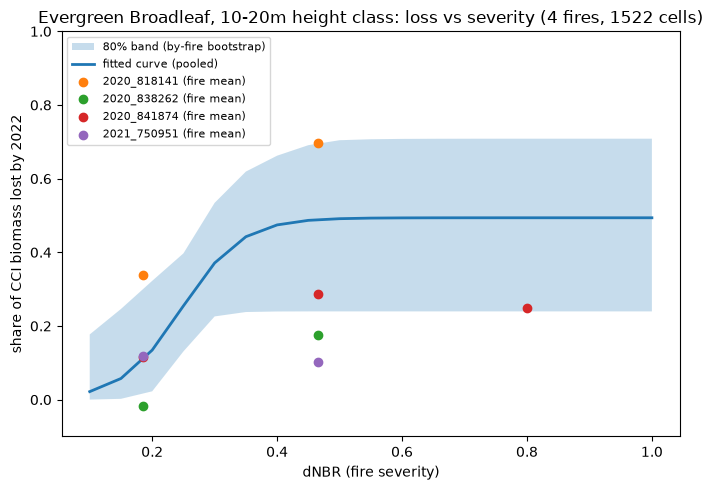

In [39]:
import matplotlib.pyplot as plt
from src.curves import fit_group, bootstrap_curve_band, logistic

# the clean group only: evergreen_broadleaf, 10-20m (excludes the degenerate <10m cells)
eb_10_20 = eb[eb["height_class"] == "10-20m"]
print("fires:", eb_10_20["uid"].nunique(), " cells:", len(eb_10_20))

fit = fit_group(eb_10_20)
print(fit)
band = bootstrap_curve_band(eb_10_20)
print(band)

x_grid = band["dnbr"]
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(x_grid, band["p10"], band["p90"], alpha=0.25, label="80% band (by-fire bootstrap)")
ax.plot(x_grid, logistic(x_grid, fit["l_max"], fit["k"], fit["x0"]), label="fitted curve (pooled)", linewidth=2)

# overlay the actual per-fire severity means as points, so the real spread is visible
sev_mid = {"mild": 0.185, "moderate": 0.465, "severe": 0.8}   # midpoints of each severity band
for uid, grp in eb_10_20.groupby("uid"):
    means = grp.groupby("severity", observed=True)["loss2022"].mean()
    xs = [sev_mid[s] for s in means.index]
    ax.scatter(xs, means.values, label=f"{uid} (fire mean)", zorder=5)

ax.set_xlabel("dNBR (fire severity)")
ax.set_ylabel("share of CCI biomass lost by 2022")
ax.set_title("Evergreen Broadleaf, 10-20m height class: loss vs severity (4 fires, 1522 cells)")
ax.legend(fontsize=8)
ax.set_ylim(-0.1, 1.0)
fig.tight_layout()
fig.savefig("../data/processed/evergreen_broadleaf_10_20m_curve.png", dpi=150)
plt.show()
